In [1]:
import os
import re
import csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer

# Only need stopwords + wordnet
nltk.download('stopwords')
nltk.download('wordnet')

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

INPUT_FILE = "M1_Reviews_Enriched_For_M2.csv"
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


[nltk_data] Downloading package stopwords to
[nltk_data]     /home/b47d5317-d063-4e78-85a3-
[nltk_data]     bac64aba1ffc/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /home/b47d5317-d063-4e78-85a3-
[nltk_data]     bac64aba1ffc/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [2]:
# STEP 1: LOAD CLEAN REVIEWS

df = pd.read_csv(INPUT_FILE)
print("Loaded shape:", df.shape)
print(df.head())

required_cols = [
    "App",
    "Translated_Review",
    "Sentiment",
    "Sentiment_Polarity",
    "Sentiment_Subjectivity",
    "Review_Length",
    "Rating",
    "VADER_Compound",
    "Sentiment_VADER",
]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns from M1 output: {missing}")


Loaded shape: (1561, 9)
                     App                                  Translated_Review  \
0  10 Best Foods for You  I like eat delicious food. That's I'm cooking ...   
1  10 Best Foods for You  I like eat delicious food. That's I'm cooking ...   
2  10 Best Foods for You    This help eating healthy exercise regular basis   
3  10 Best Foods for You    This help eating healthy exercise regular basis   
4  10 Best Foods for You         Works great especially going grocery store   

  Sentiment  Sentiment_Polarity  Sentiment_Subjectivity  Review_Length  \
0  Positive                1.00                0.533333            122   
1  Positive                1.00                0.533333            122   
2  Positive                0.25                0.288462             47   
3  Positive                0.25                0.288462             47   
4  Positive                0.40                0.875000             42   

   Rating  VADER_Compound Sentiment_VADER  
0     4.0   

In [3]:
# STEP 2: TEXT PREPROCESSING 

# Lowercasing
df["text_lower"] = df["Translated_Review"].astype(str).str.lower()

# Remove URLs and emails
url_email_pattern = r"(http\S+|www\.\S+|\S+@\S+)"
df["text_no_url"] = df["text_lower"].apply(lambda x: re.sub(url_email_pattern, " ", x))

# Keep letters, numbers, spaces only
df["text_alnum"] = df["text_no_url"].apply(lambda x: re.sub(r"[^a-z0-9\s]", " ", x))

# Normalize whitespace
df["text_clean_basic"] = df["text_alnum"].str.replace(r"\s+", " ", regex=True).str.strip()

# Simple whitespace tokenization
def simple_tokenize(text):
    return [t for t in text.split() if t]

df["tokens_raw"] = df["text_clean_basic"].apply(simple_tokenize)

# Stopword removal
stop_words = set(stopwords.words("english"))
extra_stops = {"app", "apps", "fit", "fitness", "use", "using"}
stop_words.update(extra_stops)

def remove_stopwords(tokens):
    return [t for t in tokens if t not in stop_words and len(t) > 1]

df["tokens_nostop"] = df["tokens_raw"].apply(remove_stopwords)

# Lemmatization
lemmatizer = WordNetLemmatizer()

def lemmatize_tokens(tokens):
    return [lemmatizer.lemmatize(t) for t in tokens]

df["tokens_lemma"] = df["tokens_nostop"].apply(lemmatize_tokens)

# Final clean text
df["CleanReview"] = df["tokens_lemma"].apply(lambda toks: " ".join(toks))

print("Sample CleanReview:")
print(df[["Translated_Review", "CleanReview"]].head())


Sample CleanReview:
                                   Translated_Review  \
0  I like eat delicious food. That's I'm cooking ...   
1  I like eat delicious food. That's I'm cooking ...   
2    This help eating healthy exercise regular basis   
3    This help eating healthy exercise regular basis   
4         Works great especially going grocery store   

                                         CleanReview  
0  like eat delicious food cooking food case 10 b...  
1  like eat delicious food cooking food case 10 b...  
2         help eating healthy exercise regular basis  
3         help eating healthy exercise regular basis  
4          work great especially going grocery store  


In [4]:
# STEP 3: TF-IDF KEYWORD EXTRACTION
vectorizer = TfidfVectorizer(
    max_features=100,
    min_df=2,
    max_df=0.9,
)
tfidf_matrix = vectorizer.fit_transform(df["CleanReview"])
feature_names = vectorizer.get_feature_names_out()

avg_tfidf_scores = tfidf_matrix.mean(axis=0).A1
tfidf_df = pd.DataFrame({
    "term": feature_names,
    "avg_tfidf": avg_tfidf_scores
}).sort_values("avg_tfidf", ascending=False)

top50_tfidf = tfidf_df.head(50).reset_index(drop=True)
print("Top 10 TF-IDF keywords:")
print(top50_tfidf.head(10))

os.makedirs("outputs_M2", exist_ok=True)
top50_tfidf.to_csv("outputs_M2/M2_Top50_TFIDF_Keywords.csv", index=False)
print("Saved: outputs_M2/M2_Top50_TFIDF_Keywords.csv")


Top 10 TF-IDF keywords:
      term  avg_tfidf
0     food   0.065159
1    great   0.063248
2     good   0.062636
3     love   0.049730
4     like   0.049553
5     easy   0.043727
6  calorie   0.042692
7     work   0.041720
8    track   0.037739
9   really   0.037456
Saved: outputs_M2/M2_Top50_TFIDF_Keywords.csv


In [5]:
# STEP 4: FEATURE CATEGORY IDENTIFICATION 

FEATURE_CATEGORIES = {
    "Workout_Tracking": ["workout", "exercise", "training", "sets", "reps", "routine"],
    "Calorie_Nutrition": ["calorie", "calories", "food", "nutrition", "diet", "meal"],
    "UI_UX": ["ui", "interface", "design", "easy", "simple", "complicated"],
    "Sync_Integration": ["sync", "syncing", "connect", "integration", "fitbit", "garmin"],
    "Offline_Mode": ["offline", "internet", "connection", "download"],
    "Premium_Subscription": ["premium", "subscription", "paid", "price", "expensive", "free"],
    "Bug_Technical": ["bug", "crash", "error", "freeze", "slow", "loading"],
    "Customer_Support": ["support", "help", "customer", "service", "response"],
}

def contains_any_keyword(tokens, keywords):
    token_set = set(tokens)
    return int(any(k in token_set for k in keywords))

for cat, keywords in FEATURE_CATEGORIES.items():
    col_name = f"Feature_{cat}"
    df[col_name] = df["tokens_lemma"].apply(lambda toks, kw=keywords: contains_any_keyword(toks, kw))

feature_cols = [f"Feature_{c}" for c in FEATURE_CATEGORIES.keys()]
feature_counts = df[feature_cols].sum().reset_index()
feature_counts.columns = ["Feature_Flag", "Count"]
feature_counts["Feature_Category"] = feature_counts["Feature_Flag"].str.replace("Feature_", "", regex=False)

total_reviews = df.shape[0]
feature_counts["Pct_of_Reviews"] = feature_counts["Count"] / total_reviews * 100

feature_counts = feature_counts[["Feature_Category", "Count", "Pct_of_Reviews"]].sort_values("Count", ascending=False)
print("Feature mention counts:")
print(feature_counts)

feature_counts.to_csv("outputs_M2/M2_Feature_Mention_Counts.csv", index=False)
print("Saved: outputs_M2/M2_Feature_Mention_Counts.csv")


Feature mention counts:
       Feature_Category  Count  Pct_of_Reviews
1     Calorie_Nutrition    585       37.475977
2                 UI_UX    244       15.631006
0      Workout_Tracking    215       13.773222
7      Customer_Support    146        9.352979
5  Premium_Subscription    140        8.968610
6         Bug_Technical    124        7.943626
3      Sync_Integration    112        7.174888
4          Offline_Mode     33        2.114029
Saved: outputs_M2/M2_Feature_Mention_Counts.csv


In [6]:
# STEP 5: SENTIMENT BY FEATURE CATEGORY

records = []
for cat in FEATURE_CATEGORIES.keys():
    col = f"Feature_{cat}"
    subset = df[df[col] == 1]
    n = subset.shape[0]
    if n == 0:
        avg_pol = pos_pct = neg_pct = neu_pct = net_sent = np.nan
    else:
        avg_pol = subset["Sentiment_Polarity"].mean()
        pos_pct = (subset["Sentiment_VADER"] == "Positive").mean() * 100
        neg_pct = (subset["Sentiment_VADER"] == "Negative").mean() * 100
        neu_pct = (subset["Sentiment_VADER"] == "Neutral").mean() * 100
        net_sent = pos_pct - neg_pct

    records.append({
        "Feature_Category": cat,
        "Review_Count": n,
        "Avg_Sentiment_Polarity": avg_pol,
        "Positive_%": pos_pct,
        "Neutral_%": neu_pct,
        "Negative_%": neg_pct,
        "Net_Sentiment_%": net_sent,
    })

feature_sentiment_df = pd.DataFrame(records).sort_values("Review_Count", ascending=False)
print("Sentiment by feature category:")
print(feature_sentiment_df)

feature_sentiment_df.to_csv("outputs_M2/M2_Feature_Sentiment.csv", index=False)
print("Saved: outputs_M2/M2_Feature_Sentiment.csv")


Sentiment by feature category:
       Feature_Category  Review_Count  Avg_Sentiment_Polarity  Positive_%  \
1     Calorie_Nutrition           585                0.315637   89.914530   
2                 UI_UX           244                0.299173   92.213115   
0      Workout_Tracking           215                0.322698   94.883721   
7      Customer_Support           146                0.303235   97.260274   
5  Premium_Subscription           140                0.314617   85.714286   
6         Bug_Technical           124                0.179502   67.741935   
3      Sync_Integration           112                0.249855   75.892857   
4          Offline_Mode            33                0.057031   51.515152   

   Neutral_%  Negative_%  Net_Sentiment_%  
1   4.102564    5.982906        83.931624  
2   0.000000    7.786885        84.426230  
0   0.000000    5.116279        89.767442  
7   0.000000    2.739726        94.520548  
5   0.000000   14.285714        71.428571  
6   9.67741

In [7]:
# STEP 6: SPECIFIC FEATURE REQUESTS

request_patterns = [
    r"\bneed\b", r"\bneeds\b", r"should have",
    r"would like", r"\bwant\b", r"\bwish\b",
    r"missing", r"lack of", r"doesnt have", r"doesn't have",
    r"\badd\b", r"please add", r"include"
]
pattern_re = re.compile("|".join(request_patterns), flags=re.IGNORECASE)

df["Has_Request_Phrase"] = df["Translated_Review"].astype(str).apply(lambda x: bool(pattern_re.search(x)))

request_df = df[df["Has_Request_Phrase"]].copy()
print("Reviews with request phrases:", request_df.shape[0])

request_df["text_lower_orig"] = request_df["Translated_Review"].str.lower()

REQUEST_CATEGORIES = {
    "Offline_mode": ["offline"],
    "Wearable_integration": ["apple watch", "fitbit", "garmin", "wearable"],
    "Rest_timer": ["rest timer", "rest time", "timer between sets"],
    "Dark_mode": ["dark mode", "night mode"],
    "Custom_workout_builder": ["custom workout", "create workout", "build workout"],
    "Social_features": ["social", "community", "friends", "challenge", "challenges"],
    "Progress_photos": ["progress photo", "progress picture", "before after"],
    "Meal_planning": ["meal plan", "meal planning", "meal planner"],
    "Water_intake_tracking": ["water tracker", "water tracking", "water intake"],
    "Export_data": ["export data", "export workout", "csv", "pdf"],
}

def categorize_request(text):
    text = text.lower()
    matched = []
    for cat, kws in REQUEST_CATEGORIES.items():
        if any(kw in text for kw in kws):
            matched.append(cat)
    if not matched:
        matched.append("Other")
    return matched

request_df["Request_Categories"] = request_df["text_lower_orig"].apply(categorize_request)
request_exploded = request_df.explode("Request_Categories").rename(columns={"Request_Categories": "Request_Category"})

request_counts = (
    request_exploded.groupby("Request_Category")["Translated_Review"]
    .count()
    .reset_index(name="Count")
    .sort_values("Count", ascending=False)
)
print("Feature request counts:")
print(request_counts)

os.makedirs("outputs_M2", exist_ok=True)
request_counts.to_csv("outputs_M2/M2_Feature_Request_Counts.csv", index=False)
request_exploded[["App", "Translated_Review", "Request_Category"]].to_csv(
    "outputs_M2/M2_Feature_Request_Reviews.csv", index=False
)
print("Saved: M2_Feature_Request_Counts.csv and M2_Feature_Request_Reviews.csv")


Reviews with request phrases: 352
Feature request counts:
        Request_Category  Count
2                  Other    306
5   Wearable_integration     21
3        Social_features     11
0          Meal_planning      6
4  Water_intake_tracking      6
1           Offline_mode      2
Saved: M2_Feature_Request_Counts.csv and M2_Feature_Request_Reviews.csv


In [8]:
# STEP 7: EMOTION ANALYSIS 

EMOTIONS = ["joy", "trust", "anticipation", "surprise", "anger", "fear", "sadness", "disgust"]

def load_nrc_lexicon_from_file(path="NRC-Emotion-Lexicon-Wordlevel-v0.92.txt"):
    if not os.path.exists(path):
        print(f"NRC lexicon file not found at '{path}'. Skipping emotion analysis step.")
        return None

    lex = {}
    emotions_set = set(EMOTIONS)
    with open(path, "r", encoding="utf-8") as f:
        reader = csv.reader(f, delimiter="\t")
        for row in reader:
            if len(row) != 3:
                continue
            word, emotion, assoc = row
            if emotion not in emotions_set or assoc != "1":
                continue
            if word not in lex:
                lex[word] = {}
            lex[word][emotion] = 1
    return lex

nrc_lexicon = load_nrc_lexicon_from_file("NRC-Emotion-Lexicon-Wordlevel-v0.92.txt")

if nrc_lexicon is None:
    overall_emotion_counts = pd.DataFrame({
        "Emotion": EMOTIONS,
        "Word_Count": [0]*len(EMOTIONS),
        "Pct_of_Reviews_with_EmotionWord": [0.0]*len(EMOTIONS),
    })
    emotion_by_app = pd.DataFrame(columns=["App"] + EMOTIONS)
    print("Emotion analysis skipped; using zero counts.")
else:
    def count_emotions(tokens):
        counts = {e: 0 for e in EMOTIONS}
        for t in tokens:
            emo_info = nrc_lexicon.get(t, {})
            for e in EMOTIONS:
                if emo_info.get(e, 0) == 1:
                    counts[e] += 1
        return counts

    emotion_records = []
    for idx, row in df.iterrows():
        counts = count_emotions(row["tokens_lemma"])
        counts["App"] = row["App"]
        emotion_records.append(counts)

    emotion_df = pd.DataFrame(emotion_records)

    overall_emotion_counts = emotion_df[EMOTIONS].sum().reset_index()
    overall_emotion_counts.columns = ["Emotion", "Word_Count"]
    overall_emotion_counts["Pct_of_Reviews_with_EmotionWord"] = (
        (emotion_df[EMOTIONS] > 0).sum() / df.shape[0] * 100
    ).values

    emotion_by_app = (
        emotion_df.groupby("App")[EMOTIONS]
        .sum()
        .reset_index()
    )

os.makedirs("outputs_M2", exist_ok=True)
overall_emotion_counts.to_csv("outputs_M2/M2_Emotion_Overall.csv", index=False)
emotion_by_app.to_csv("outputs_M2/M2_Emotion_By_App.csv", index=False)
print("Saved: M2_Emotion_Overall.csv and M2_Emotion_By_App.csv")

# Show some output so you see it ran
print("Overall emotion counts (first rows):")
display(overall_emotion_counts.head())
print("Emotion counts by app (first rows):")
display(emotion_by_app.head())


Saved: M2_Emotion_Overall.csv and M2_Emotion_By_App.csv
Overall emotion counts (first rows):


,Emotion,Word_Count,Pct_of_Reviews_with_EmotionWord
0,joy,2030,63.933376
1,trust,2204,66.880205
2,anticipation,1695,58.103780
3,surprise,687,31.710442
4,anger,379,19.154388


Emotion counts by app (first rows):


,App,joy,trust,anticipation,surprise,anger,fear,sadness,disgust
0,10 Best Foods for You,154,144,94,58,8,16,22,10
1,8fit Workouts & Meal Planner,284,272,274,72,46,72,126,38
2,Calorie Counter & Diet Tracker,290,336,276,116,80,108,160,78
3,Calorie Counter - Macros,460,492,298,134,82,176,182,116
4,Calorie Counter - MyFitnessPal,530,610,485,165,105,195,200,135


In [9]:
# STEP 8: COMPETITIVE ANALYSIS

top5_apps = (
    df.groupby("App")["Translated_Review"]
    .count()
    .reset_index(name="Review_Count")
    .sort_values("Review_Count", ascending=False)
    .head(5)
)
top5_names = top5_apps["App"].tolist()
df_top5 = df[df["App"].isin(top5_names)].copy()

app_avg_rating = df_top5.groupby("App")["Rating"].mean().reset_index(name="Avg_Rating")
app_avg_sentiment = df_top5.groupby("App")["Sentiment_Polarity"].mean().reset_index(name="Avg_Sentiment_Polarity")

records = []
for app in top5_names:
    app_subset = df_top5[df_top5["App"] == app]
    for cat in FEATURE_CATEGORIES.keys():
        col = f"Feature_{cat}"
        sub_feature = app_subset[app_subset[col] == 1]
        if sub_feature.empty:
            continue
        avg_pol = sub_feature["Sentiment_Polarity"].mean()
        records.append({
            "App": app,
            "Feature_Category": cat,
            "Avg_Polarity": avg_pol,
            "Count": sub_feature.shape[0],
        })

app_feature_sent = pd.DataFrame(records)

top_complaints = []
top_praises = []
for app in top5_names:
    sub = app_feature_sent[app_feature_sent["App"] == app]
    if sub.empty:
        top_complaints.append({"App": app, "Top_Complaint": None})
        top_praises.append({"App": app, "Top_Praise": None})
        continue
    top_compl = sub.sort_values("Avg_Polarity").iloc[0]["Feature_Category"]
    top_praise = sub.sort_values("Avg_Polarity", ascending=False).iloc[0]["Feature_Category"]
    top_complaints.append({"App": app, "Top_Complaint": top_compl})
    top_praises.append({"App": app, "Top_Praise": top_praise})

top_complaints_df = pd.DataFrame(top_complaints)
top_praises_df = pd.DataFrame(top_praises)

app_summary = (
    top5_apps.merge(app_avg_rating, on="App", how="left")
    .merge(app_avg_sentiment, on="App", how="left")
    .merge(top_complaints_df, on="App", how="left")
    .merge(top_praises_df, on="App", how="left")
)

print("App-level summary (top 5 apps):")
display(app_summary)

app_summary.to_csv("outputs_M2/M2_App_Summary_Top5.csv", index=False)
print("Saved: outputs_M2/M2_App_Summary_Top5.csv")


App-level summary (top 5 apps):


,App,Review_Count,Avg_Rating,Avg_Sentiment_Polarity,Top_Complaint,Top_Praise
0,Calorie Counter - MyFitnessPal,475,4.6,0.219104,Offline_Mode,Workout_Tracking
1,8fit Workouts & Meal Planner,200,4.6,0.297167,Offline_Mode,UI_UX
2,Calorie Counter - Macros,200,4.0,0.247519,Workout_Tracking,Premium_Subscription
3,Calorie Counter & Diet Tracker,194,4.5,0.218263,Sync_Integration,Workout_Tracking
4,Calorie Counter - MyNetDiary,192,4.5,0.399905,Bug_Technical,Workout_Tracking


Saved: outputs_M2/M2_App_Summary_Top5.csv


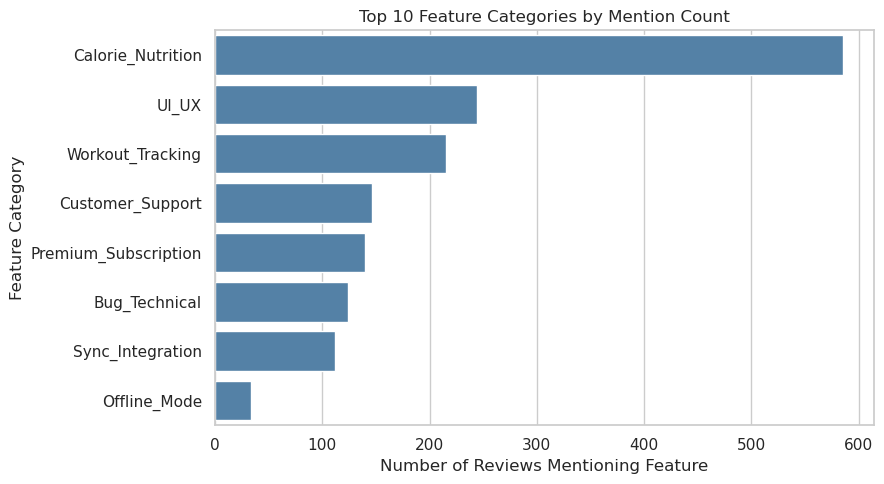

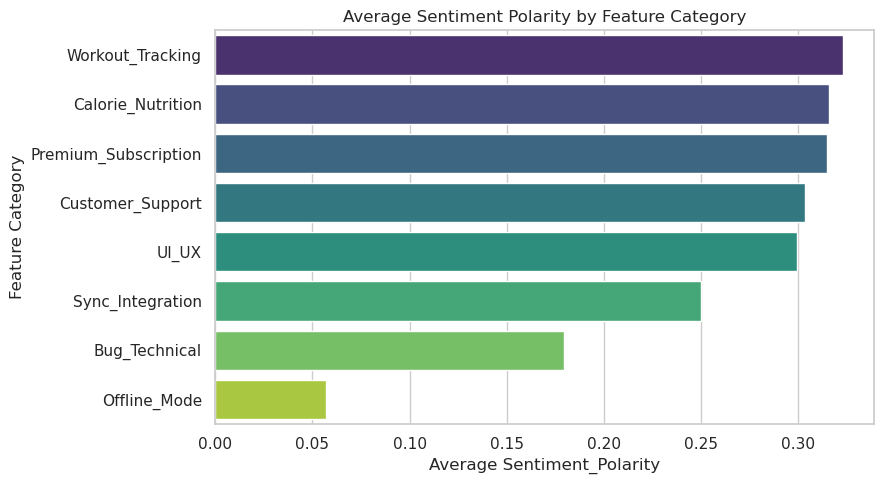

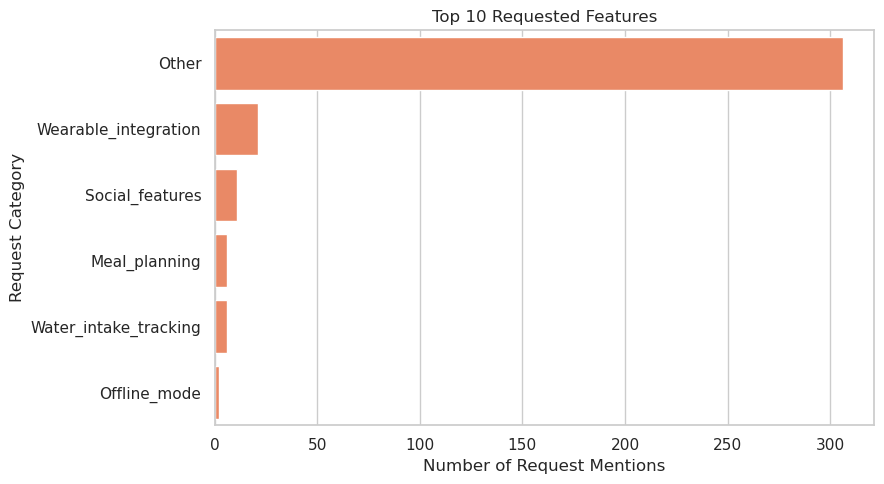

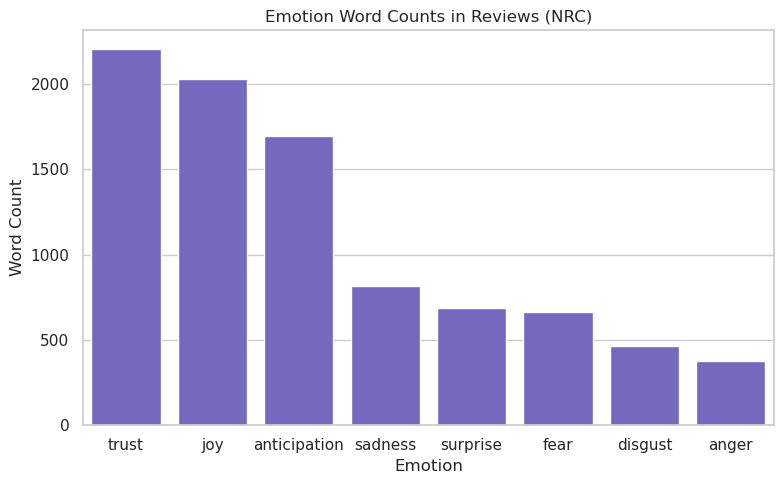

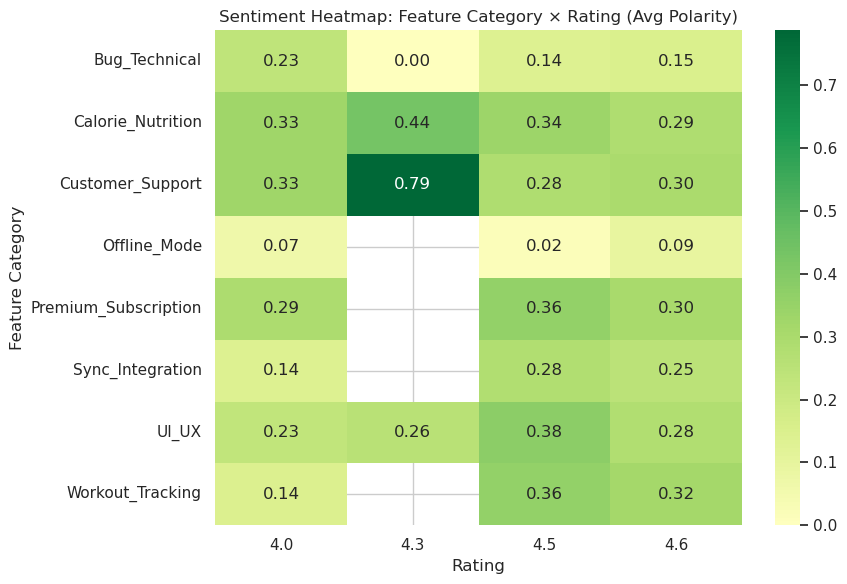

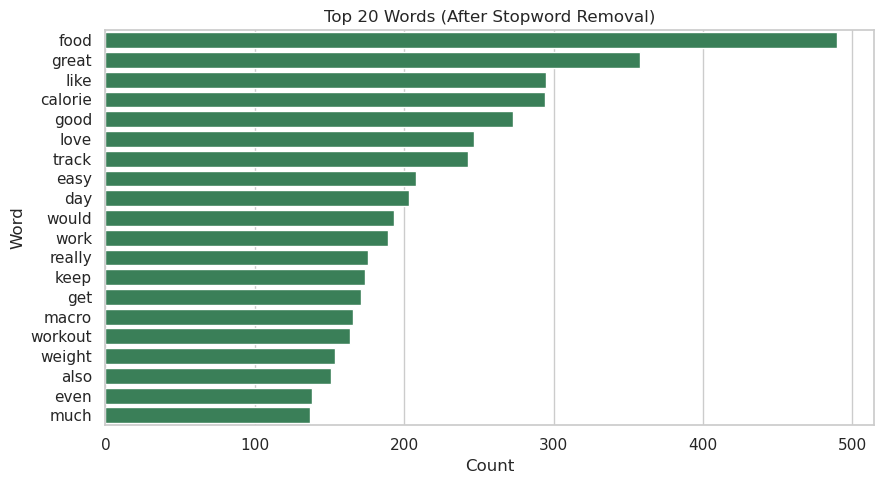

Saved and displayed all required M2 figures in ./figures_M2


In [10]:
# STEP 9: VISUALIZATIONS 

os.makedirs("figures_M2", exist_ok=True)

# 1. Feature Mentions
feat10 = feature_counts.sort_values("Count", ascending=False).head(10)
plt.figure(figsize=(9, 5))
sns.barplot(data=feat10, x="Count", y="Feature_Category", color="steelblue")
plt.title("Top 10 Feature Categories by Mention Count")
plt.xlabel("Number of Reviews Mentioning Feature")
plt.ylabel("Feature Category")
plt.tight_layout()
plt.savefig("figures_M2/Feature_Mentions_Top10.png", dpi=300)
plt.show()
plt.close()

# 2. Sentiment by Feature
plt.figure(figsize=(9, 5))
sns.barplot(
    data=feature_sentiment_df.sort_values("Avg_Sentiment_Polarity", ascending=False),
    x="Avg_Sentiment_Polarity",
    y="Feature_Category",
    palette="viridis"
)
plt.title("Average Sentiment Polarity by Feature Category")
plt.xlabel("Average Sentiment_Polarity")
plt.ylabel("Feature Category")
plt.tight_layout()
plt.savefig("figures_M2/Sentiment_by_Feature.png", dpi=300)
plt.show()
plt.close()

# 3. Feature Request Frequency
req10 = request_counts.sort_values("Count", ascending=False).head(10)
plt.figure(figsize=(9, 5))
sns.barplot(data=req10, x="Count", y="Request_Category", color="coral")
plt.title("Top 10 Requested Features")
plt.xlabel("Number of Request Mentions")
plt.ylabel("Request Category")
plt.tight_layout()
plt.savefig("figures_M2/Feature_Request_Frequency_Top10.png", dpi=300)
plt.show()
plt.close()

# 4. Emotion Distribution
plt.figure(figsize=(8, 5))
sns.barplot(
    data=overall_emotion_counts.sort_values("Word_Count", ascending=False),
    x="Emotion",
    y="Word_Count",
    color="slateblue"
)
plt.title("Emotion Word Counts in Reviews (NRC)")
plt.xlabel("Emotion")
plt.ylabel("Word Count")
plt.tight_layout()
plt.savefig("figures_M2/Emotion_Distribution.png", dpi=300)
plt.show()
plt.close()

# 5. Sentiment Heatmap Feature × Rating
heat_records = []
for cat in FEATURE_CATEGORIES.keys():
    col = f"Feature_{cat}"
    subset = df[df[col] == 1]
    if subset.empty:
        continue
    avg_by_rating = subset.groupby("Rating")["Sentiment_Polarity"].mean()
    for rating, val in avg_by_rating.items():
        heat_records.append({
            "Feature_Category": cat,
            "Rating": rating,
            "Avg_Polarity": val,
        })

heat_df = pd.DataFrame(heat_records)
if not heat_df.empty:
    heat_pivot = heat_df.pivot(index="Feature_Category", columns="Rating", values="Avg_Polarity")
    plt.figure(figsize=(9, 6))
    sns.heatmap(heat_pivot, annot=True, fmt=".2f", cmap="RdYlGn", center=0)
    plt.title("Sentiment Heatmap: Feature Category × Rating (Avg Polarity)")
    plt.xlabel("Rating")
    plt.ylabel("Feature Category")
    plt.tight_layout()
    plt.savefig("figures_M2/Sentiment_Heatmap_Feature_Rating.png", dpi=300)
    plt.show()
    plt.close()
else:
    print("Heatmap skipped: no feature–rating combinations.")

# 6. Word Frequency (top 20)
from collections import Counter
all_tokens = [t for tokens in df["tokens_lemma"] for t in tokens]
freq_counter = Counter(all_tokens)
freq20 = pd.DataFrame(freq_counter.most_common(20), columns=["Word", "Count"])

plt.figure(figsize=(9, 5))
sns.barplot(data=freq20, x="Count", y="Word", color="seagreen")
plt.title("Top 20 Words (After Stopword Removal)")
plt.xlabel("Count")
plt.ylabel("Word")
plt.tight_layout()
plt.savefig("figures_M2/Word_Frequency_Top20.png", dpi=300)
plt.show()
plt.close()

print("Saved and displayed all required M2 figures in ./figures_M2")


In [11]:
# STEP 10: SUMMARY EXPORT FOR M2 REPORT


summary = {
    "Total_Reviews": [df.shape[0]],
    "Total_Apps": [df["App"].nunique()],
    "Top_Feature_By_Mentions": [feature_counts.iloc[0]["Feature_Category"] if not feature_counts.empty else None],
    "Most_Positive_Feature": [
        feature_sentiment_df.sort_values("Avg_Sentiment_Polarity", ascending=False).iloc[0]["Feature_Category"]
        if not feature_sentiment_df["Avg_Sentiment_Polarity"].isna().all() else None
    ],
    "Most_Negative_Feature": [
        feature_sentiment_df.sort_values("Avg_Sentiment_Polarity").iloc[0]["Feature_Category"]
        if not feature_sentiment_df["Avg_Sentiment_Polarity"].isna().all() else None
    ],
    "Top_Request_Category": [request_counts.iloc[0]["Request_Category"] if not request_counts.empty else None],
}
summary_df = pd.DataFrame(summary)
summary_df.to_csv("outputs_M2/M2_Summary_Stats.csv", index=False)
print("Saved: outputs_M2/M2_Summary_Stats.csv")


Saved: outputs_M2/M2_Summary_Stats.csv
